<a href="https://colab.research.google.com/github/kimeliwesley-del/kimeliwesley-del/blob/main/Random%20Forest%20%20_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import ee
import geemap
import rasterio
import numpy as np
import geopandas



In [ ]:
from google.colab import output
output.enable_custom_widget_manager()

In [ ]:
# Trigger the authentication flow.
ee.Authenticate()

# Initialize the library.
ee.Initialize(project='ee-kimeliwesley')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Define a spatial extend of the area of Interest, a polygon

In [ ]:
aoi = ee.Geometry.Polygon([
  [
    [33.93545, 0.77479],
    [35.62120, 0.77479],
    [35.62120, -0.57851],
    [33.93545, -0.57851],
    [33.93545, 0.77479]
  ]
])
Map = geemap.Map()
Map.centerObject(aoi, 8)
Map.addLayer(aoi, {'color': 'red'}, 'AOI')
Map

Map(center=[0.09814605450015873, 34.778324999999974], controls=(WidgetControl(options=['position', 'transparen…

Get geometrically corrected data, T1_L2 Data from 1985 to 1986

In [ ]:
collection = (
    ee.ImageCollection("LANDSAT/LT05/C02/T1_L2")
    .filterBounds(aoi)
    .filterDate("1985-01-01", "1986-12-31")
    .select(["SR_B1", "SR_B2", "SR_B3", "SR_B4", "SR_B5", "SR_B7"])
)

In [ ]:
print(f"Number of images in collection: {collection.size().getInfo()}")

Number of images in collection: 71


### Landsat 5 image is in Surface Relectance value and scaing factor already applied. Cloud masking will be erformed to remove cloudy pixels from the image through cloud masking

In [ ]:
def mask_l5(image):
    qa = image.select('QA_PIXEL')

    mask = (
        qa.bitwiseAnd(1 << 4).eq(0)  # cloud shadow
        .And(qa.bitwiseAnd(1 << 3).eq(0))  # cloud
        .And(qa.bitwiseAnd(1 << 2).eq(0))  # cirrus
    )
    return image.updateMask(mask)
image = collection.median().clip(aoi)
print(image.getInfo())

{'type': 'Image', 'bands': [{'id': 'SR_B1', 'data_type': {'type': 'PixelType', 'precision': 'double', 'min': 0, 'max': 65535}, 'dimensions': [4, 4], 'origin': [33, -2], 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}, {'id': 'SR_B2', 'data_type': {'type': 'PixelType', 'precision': 'double', 'min': 0, 'max': 65535}, 'dimensions': [4, 4], 'origin': [33, -2], 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}, {'id': 'SR_B3', 'data_type': {'type': 'PixelType', 'precision': 'double', 'min': 0, 'max': 65535}, 'dimensions': [4, 4], 'origin': [33, -2], 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}, {'id': 'SR_B4', 'data_type': {'type': 'PixelType', 'precision': 'double', 'min': 0, 'max': 65535}, 'dimensions': [4, 4], 'origin': [33, -2], 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}, {'id': 'SR_B5', 'data_type': {'type': 'PixelType', 'precision': 'double', 'min': 0, 'max': 65535}, 'dimensions': [4, 4], 'origin': [33, -2], 'crs': 'EPSG:4326', 'crs_transform'

### To enhance the visualization,calculate the mean and standard deviation of the selected bands red #B3,green #B2 and blue #B1 for creating true color composite and apply a 2-standard deviation stretch. To set the minimum and maximum visualization parameters.


In [ ]:
def compute_2sd_stretch(image, region, bands):
    """
    Computes a 2-standard-deviation stretch for visualization.

    Parameters:
    image  : ee.Image (composited image)
    region : ee.Geometry (AOI)
    bands  : list of band names (e.g. ['SR_B3','SR_B2','SR_B1'])

    Returns:
    dict with min, max, and gamma values
    """

    stats = image.select(bands).reduceRegion(
        reducer=ee.Reducer.mean().combine(
            ee.Reducer.stdDev(),
            sharedInputs=True
        ),
        geometry=region,
        scale=1000,
        maxPixels=1e9
    )

    means = []
    stds = []

    for b in bands:
        means.append(stats.get(f"{b}_mean").getInfo() or 0)
        stds.append(stats.get(f"{b}_stdDev").getInfo() or 0)

    mean = sum(means) / len(means)
    std = sum(stds) / len(stds)

    stretch_min = max(0, mean - 2 * std)
    stretch_max = mean + 2 * std

    return {
        "min": stretch_min,
        "max": stretch_max,
        "gamma": 1.2
    }

Based on the maximum and minimum stretch add the true color image layer to map.

In [ ]:
bands_for_stretch = ["SR_B3", "SR_B2", "SR_B1"]
stretch_params = compute_2sd_stretch(image, aoi, bands_for_stretch)

new_min_stretch = stretch_params['min']
new_max_stretch = stretch_params['max']

vis_params_sd_stretch = {
    "min": new_min_stretch,
    "max": new_max_stretch,
    "bands": bands_for_stretch
}
if 'Map' not in locals() or not isinstance(Map, geemap.Map):
    Map = geemap.Map()
Map.addLayer(image, vis_params_sd_stretch, "Landsat")
Map.addLayerControl()
Map

Map(bottom=65836.0, center=[0, 34.78546142578126], controls=(WidgetControl(options=['position', 'transparent_b…



 ### Load the training data from ArcGIS to the drive and copy path.Import geopandas to dispaly the classes in  GeoJSON and display a first row

In [ ]:
gdf_new_training = geopandas.read_file('/content/drive/MyDrive/tms/ColabTrain_Dat_FeaturesToJSO.geojson')
print('Original GeoDataFrame head:')
display(gdf_new_training.head())

Original GeoDataFrame head:


,OBJECTID,Classcode,Classname,Classvalue,RED,GREEN,BLUE,Count,Shape_Length,Shape_Area,geometry
0,1,,Forest,1,76,115,0,2,213.775004,2464.806482,"POLYGON ((35.04547 0.11625, 35.04515 0.11683, ..."
1,2,,Forest,1,76,115,0,8,343.277909,7348.562831,"POLYGON ((35.06201 0.12682, 35.06129 0.12717, ..."
2,3,,Forest,1,76,115,0,10,392.844287,9644.401598,"POLYGON ((35.04671 0.0857, 35.04587 0.08596, 3..."
3,4,,Forest,1,76,115,0,5,291.371329,5302.756501,"POLYGON ((35.02225 0.07336, 35.02159 0.0735, 3..."
4,5,,Forest,1,76,115,0,6,314.191723,6168.813400,"POLYGON ((35.01435 0.07082, 35.01363 0.07083, ..."


Convert the training data Object to a string

In [ ]:
gdf_new_training['OBJECTID'] = gdf_new_training['OBJECTID'].astype(str)
new_temp_geojson_path = '/content/ColabTrain_Dat_FeaturesToJSO.geojson'
gdf_new_training.to_file(new_temp_geojson_path, driver='GeoJSON')

print(f"Modified GeoJSON saved to: {new_temp_geojson_path}")
print('Modified GeoDataFrame head:')
display(gdf_new_training.head())

Modified GeoJSON saved to: /content/ColabTrain_Dat_FeaturesToJSO.geojson
Modified GeoDataFrame head:


,OBJECTID,Classcode,Classname,Classvalue,RED,GREEN,BLUE,Count,Shape_Length,Shape_Area,geometry
0,1,,Forest,1,76,115,0,2,213.775004,2464.806482,"POLYGON ((35.04547 0.11625, 35.04515 0.11683, ..."
1,2,,Forest,1,76,115,0,8,343.277909,7348.562831,"POLYGON ((35.06201 0.12682, 35.06129 0.12717, ..."
2,3,,Forest,1,76,115,0,10,392.844287,9644.401598,"POLYGON ((35.04671 0.0857, 35.04587 0.08596, 3..."
3,4,,Forest,1,76,115,0,5,291.371329,5302.756501,"POLYGON ((35.02225 0.07336, 35.02159 0.0735, 3..."
4,5,,Forest,1,76,115,0,6,314.191723,6168.813400,"POLYGON ((35.01435 0.07082, 35.01363 0.07083, ..."


### Using geemap, Read the converted training data in GEE format as spatial features since GEE cannot directly read GeoJson files
- confirm if labels are correct
-check the structure before training

In [ ]:
training = geemap.geojson_to_ee('/content/ColabTrain_Dat_FeaturesToJSO.geojson')
training = ee.FeatureCollection(training.toList(training.size()))

print('\nFirst feature of the preprocessed Earth Engine training collection:')
print(training.first().getInfo())


First feature of the preprocessed Earth Engine training collection:
{'type': 'Feature', 'geometry': {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[35.04547284825429, 0.116253132553717], [35.04515181359466, 0.116830983983413], [35.04488798301612, 0.116682426982005], [35.04520901778574, 0.116104575489546], [35.04547284825429, 0.116253132553717]]]}, 'id': '0', 'properties': {'BLUE': 0, 'Classcode': '', 'Classname': 'Forest', 'Classvalue': 1, 'Count': 2, 'GREEN': 115, 'OBJECTID': '1', 'RED': 76, 'Shape_Area': 2464.8064824933354, 'Shape_Length': 213.77500435241535}}


### Rewriting the features to in the training dataset before training the classifier maintaining the polygon geometry, rename the training data as class and extracting attribute of each class

In [ ]:
training = training.map(lambda f: ee.Feature(
    f.geometry(),
    {'class': ee.Number(f.get('Classvalue'))}
))

### Converting the satellite data into machine learning data
 Specify the spectral Bands and extract pixel values from all input bands to train the model,
 check the number of training samples before training of the training Data,Split the training and the test data used  to evaluate the model.

In [ ]:
input_bands = image.select(['SR_B1','SR_B2','SR_B3','SR_B4','SR_B5','SR_B7'])

print(f"Size of training collection before sampling: {training.size().getInfo()}")
print(f"First feature of training collection before sampling: {training.first().getInfo()}")

samples = input_bands.sampleRegions(
    collection=training,
    properties=['class'],
    scale=30,
    tileScale=16
)

print(f"Total samples: {samples.size().getInfo()}")

samples = samples.randomColumn('random')

train = samples.filter('random < 0.7')
test = samples.filter('random >= 0.7')

print(f"Training samples: {train.size().getInfo()}")
print(f"Testing samples: {test.size().getInfo()}")
display('training samples :', train.limit(5))
display('test samples :', test.limit(5))

Size of training collection before sampling: 680
First feature of training collection before sampling: {'type': 'Feature', 'geometry': {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[35.04547284825429, 0.116253132553717], [35.04515181359466, 0.116830983983413], [35.04488798301612, 0.116682426982005], [35.04520901778574, 0.116104575489546], [35.04547284825429, 0.116253132553717]]]}, 'id': '0', 'properties': {'class': 1}}
Total samples: 5581
Training samples: 3897
Testing samples: 1684


'training samples :'

'test samples :'

Train Random Forest Algorithm Classifier, specify the number of trees, minLeafpopulation, and maxnodes

In [ ]:
classifier = ee.Classifier.smileRandomForest(100,minLeafPopulation=10,maxNodes=100).train(
    features=train,
    classProperty='class',
    inputProperties=input_bands.bandNames()
)
display('Results of trained classifier', classifier.explain())

'Results of trained classifier'

###Create the confusion Matrix, Overell accuracy for training and testing data.

In [ ]:
# Get a confusion matrix and overall accuracy for the training sample.
train_accuracy = classifier.confusionMatrix()
display('Training error matrix', train_accuracy)
display('Training overall accuracy', train_accuracy.accuracy())

# Get a confusion matrix and overall accuracy for the validation sample.
validation_sample = test.classify(classifier)
# display('val samples :', validation_sample.limit(100))
validation_accuracy = validation_sample.errorMatrix('class', 'classification')
display('Validation error matrix', validation_accuracy)
display('Validation accuracy', validation_accuracy.accuracy())

'Training error matrix'

'Training overall accuracy'

'Validation error matrix'

'Validation accuracy'

Visualize the classified image using color palette

In [ ]:
class_names = [
    'Forest', 'Wetland', 'Agriculture', 'Grass Land',
    'Tea', 'Planted Forest', 'Water', 'Settlement', 'Hyacinth'
]

palette = [
    '#0B3D0B',  # Forest
    '#00CED1',  # Wetland
    '#E6FF66',  # Agriculture
    '#32CD32',  # Grass Land
    '#FFD700',  # Tea
    '#556B2F',  # Planted Forest
    '#1E3A8A',  # Water
    '#FF0000',  # Settlement
    '#800080'   # Hyacinth
]
classified_1985 = input_bands.classify(classifier)

Map.addLayer(classified_1985, {
    'min': 1,
    'max': 9, # Adjusted max to match 9 classes
    'palette': palette
}, 'Classified Map')
Map

Map(bottom=262166.0, center=[0.19088709804203244, 35.130844116210945], controls=(WidgetControl(options=['posit…

Get Classes

In [ ]:
class_values = train.aggregate_array('class').distinct()
print(class_values.getInfo())

[1, 2, 3, 4, 5, 6, 7, 8, 9]


Add legend  to the vizualized map,

In [ ]:
class_names = [
    'Forest', 'Wetland', 'Agriculture', 'Grass Land',
    'Tea', 'Planted Forest', 'Water', 'Settlement', 'Hyacinth'
]

palette = [
    '#0B3D0B',  # Forest
    '#00CED1',  # Wetland
    '#E6FF66',  # Agriculture
    '#32CD32',  # Grass Land
    '#FFD700',  # Tea
    '#556B2F',  # Planted Forest
    '#1E3A8A',  # Water
    '#FF0000',  # Settlement
    '#800080'   # Hyacinth
]

# Create the new legend_dict using the class_names and the new palette
legend_dict = dict(zip(class_names, palette))

Map.addLayer(classified_1985, {
    'min': 1,
    'max': 9, # Adjusted max to match 9 classes
    'palette': palette
}, 'Classified Map')

Map.add_legend(title='Land Use / Land Cover', legend_dict=legend_dict)

Map

Map(bottom=262139.0, center=[0.2094264135464264, 35.13015747070313], controls=(WidgetControl(options=['positio…

Export the image to the drive

In [ ]:
task = ee.batch.Export.image.toDrive(
    image=classified_1985,
    description='LULC_Classification_1985',
    folder='GEE_Exports',
    fileNamePrefix='lulc_2005',
    region=aoi,
    scale=30,
    maxPixels=1e13
)

task.start()

###Classify 2003 Image: This is a repetitive process of what the image classificatiob for the 1985 image

In [ ]:
aoi = ee.Geometry.Polygon([
  [
    [33.93545, 0.77479],
    [35.62120, 0.77479],
    [35.62120, -0.57851],
    [33.93545, -0.57851],
    [33.93545, 0.77479]
  ]
])
Map = geemap.Map()
Map.centerObject(aoi, 8)
Map.addLayer(aoi, {'color': 'red'}, 'AOI')
Map

Map(center=[0.09814605450015873, 34.778324999999974], controls=(WidgetControl(options=['position', 'transparen…

Get an image collection from Landsat 5 Tier 1 Level 1 for 2003-2010 date range

In [ ]:
collection = (
    ee.ImageCollection("LANDSAT/LT05/C02/T1_L2")
    .filterBounds(aoi)
    .filterDate("2003-01-01", "2010-12-31")
    .select(["SR_B1", "SR_B2", "SR_B3", "SR_B4", "SR_B5", "SR_B7"]) # Include all necessary bands for scaling and masking

)
# The 'image' variable will be defined in the next cell (S7e8jbelhxB4) after applying scale factors

In [ ]:
print(f"Number of images in collection: {collection.size().getInfo()}")

Number of images in collection: 57


Cloud Masking

In [ ]:
def mask_l5(image):
    qa = image.select('QA_PIXEL')

    mask = (
        qa.bitwiseAnd(1 << 4).eq(0)  # cloud shadow
        .And(qa.bitwiseAnd(1 << 3).eq(0))  # cloud
        .And(qa.bitwiseAnd(1 << 2).eq(0))  # cirrus
    )
    return image.updateMask(mask)
image = collection.median().clip(aoi)
print(image.getInfo())

{'type': 'Image', 'bands': [{'id': 'SR_B1', 'data_type': {'type': 'PixelType', 'precision': 'double', 'min': 0, 'max': 65535}, 'dimensions': [4, 4], 'origin': [33, -2], 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}, {'id': 'SR_B2', 'data_type': {'type': 'PixelType', 'precision': 'double', 'min': 0, 'max': 65535}, 'dimensions': [4, 4], 'origin': [33, -2], 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}, {'id': 'SR_B3', 'data_type': {'type': 'PixelType', 'precision': 'double', 'min': 0, 'max': 65535}, 'dimensions': [4, 4], 'origin': [33, -2], 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}, {'id': 'SR_B4', 'data_type': {'type': 'PixelType', 'precision': 'double', 'min': 0, 'max': 65535}, 'dimensions': [4, 4], 'origin': [33, -2], 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}, {'id': 'SR_B5', 'data_type': {'type': 'PixelType', 'precision': 'double', 'min': 0, 'max': 65535}, 'dimensions': [4, 4], 'origin': [33, -2], 'crs': 'EPSG:4326', 'crs_transform'

Stetch and visualize, True color image

In [ ]:
bands_to_stretch = ["SR_B3", "SR_B2", "SR_B1"]
region = image.geometry().bounds()  # or your AOI

stats = image.select(bands_to_stretch).reduceRegion(
    reducer=ee.Reducer.mean().combine(
        reducer2=ee.Reducer.stdDev(),
        sharedInputs=True
    ),
    geometry=region,
    scale=30,
    maxPixels=1e9
)

stats_dict = stats.getInfo()  # ONE call only

means = []
std_devs = []

for band_name in bands_to_stretch:
    mean_val = stats_dict.get(band_name + "_mean")
    std_val = stats_dict.get(band_name + "_stdDev")

    if mean_val is None or std_val is None:
        print(f"Warning: Missing stats for {band_name}")
        mean_val, std_val = 0, 1000

    means.append(mean_val)
    std_devs.append(std_val)

avg_mean = sum(means) / len(means)
avg_std = sum(std_devs) / len(std_devs)

new_min_stretch = max(0, avg_mean - 2 * avg_std)
new_max_stretch = min(65535, avg_mean + 2 * avg_std)

print(f"Min stretch: {new_min_stretch:.2f}")
print(f"Max stretch: {new_max_stretch:.2f}")

Min stretch: 7928.22
Max stretch: 11544.75


Display the image

In [ ]:
vis_params_sd_stretch = {
    "min": new_min_stretch,
    "max": new_max_stretch,
    "bands": ["SR_B3", "SR_B2", "SR_B1"]
}
if 'Map' not in locals() or not isinstance(Map, geemap.Map):
    Map = geemap.Map()
Map.addLayer(image, vis_params_sd_stretch, "Landsat")
Map.addLayerControl()
Map

Map(bottom=33136.0, center=[-0.37353251022880474, 35.93627929687501], controls=(WidgetControl(options=['positi…

Import the traing data

In [ ]:
import geopandas
training_data = geopandas.read_file('/content/drive/MyDrive/tms/ColabTrain_Dat_FeaturesToJSO.geojson')
print('Original GeoDataFrame head:')
display(training_data.head())

Original GeoDataFrame head:


,OBJECTID,Classcode,Classname,Classvalue,RED,GREEN,BLUE,Count,Shape_Length,Shape_Area,geometry
0,1,,Forest,1,76,115,0,2,213.775004,2464.806482,"POLYGON ((35.04547 0.11625, 35.04515 0.11683, ..."
1,2,,Forest,1,76,115,0,8,343.277909,7348.562831,"POLYGON ((35.06201 0.12682, 35.06129 0.12717, ..."
2,3,,Forest,1,76,115,0,10,392.844287,9644.401598,"POLYGON ((35.04671 0.0857, 35.04587 0.08596, 3..."
3,4,,Forest,1,76,115,0,5,291.371329,5302.756501,"POLYGON ((35.02225 0.07336, 35.02159 0.0735, 3..."
4,5,,Forest,1,76,115,0,6,314.191723,6168.813400,"POLYGON ((35.01435 0.07082, 35.01363 0.07083, ..."


Convert to a string

In [ ]:
training_data['OBJECTID'] = training_data['OBJECTID'].astype(str)
new_temp_geojson_path = '/content/drive/MyDrive/tms/colabTrain_Dat_featureToJSO.geojson'
training_data.to_file(new_temp_geojson_path, driver='GeoJSON')

print(f"Modified GeoJSON saved to: {new_temp_geojson_path}")
print('Modified GeoDataFrame head:')
display(training_data.head())

Modified GeoJSON saved to: /content/drive/MyDrive/tms/colabTrain_Dat_featureToJSO.geojson
Modified GeoDataFrame head:


,OBJECTID,Classcode,Classname,Classvalue,RED,GREEN,BLUE,Count,Shape_Length,Shape_Area,geometry
0,1,,Forest,1,76,115,0,2,213.775004,2464.806482,"POLYGON ((35.04547 0.11625, 35.04515 0.11683, ..."
1,2,,Forest,1,76,115,0,8,343.277909,7348.562831,"POLYGON ((35.06201 0.12682, 35.06129 0.12717, ..."
2,3,,Forest,1,76,115,0,10,392.844287,9644.401598,"POLYGON ((35.04671 0.0857, 35.04587 0.08596, 3..."
3,4,,Forest,1,76,115,0,5,291.371329,5302.756501,"POLYGON ((35.02225 0.07336, 35.02159 0.0735, 3..."
4,5,,Forest,1,76,115,0,6,314.191723,6168.813400,"POLYGON ((35.01435 0.07082, 35.01363 0.07083, ..."


Check training label before training

In [ ]:
training_2003 = geemap.geojson_to_ee('/content/drive/MyDrive/tms/colabTrain_Dat_featureToJSO.geojson')
training_2003 = ee.FeatureCollection(training_2003.toList(training_2003.size()))

print('\nFirst feature of the preprocessed Earth Engine training collection:')
print(training_2003.first().getInfo())


First feature of the preprocessed Earth Engine training collection:
{'type': 'Feature', 'geometry': {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[35.04547284825429, 0.116253132553717], [35.04515181359466, 0.116830983983413], [35.04488798301612, 0.116682426982005], [35.04520901778574, 0.116104575489546], [35.04547284825429, 0.116253132553717]]]}, 'id': '0', 'properties': {'BLUE': 0, 'Classcode': '', 'Classname': 'Forest', 'Classvalue': 1, 'Count': 2, 'GREEN': 115, 'OBJECTID': '1', 'RED': 76, 'Shape_Area': 2464.8064824933354, 'Shape_Length': 213.77500435241535}}


Extract pixel attribute

In [ ]:
training_2003 = training_2003.map(lambda f: ee.Feature(
    f.geometry(),
    {'class': ee.Number(f.get('Classvalue'))}
))

Check the number of samples, split training and valiadation

In [ ]:
input_bands = image.select(['SR_B1','SR_B2','SR_B3','SR_B4','SR_B5','SR_B7'])

print(f"Size of training collection before sampling: {training_2003.size().getInfo()}")
print(f"First feature of training collection before sampling: {training_2003.first().getInfo()}")

samples = input_bands.sampleRegions(
    collection=training_2003,
    properties=['class'],
    scale=30,
    tileScale=16
)

print(f"Total samples: {samples.size().getInfo()}")

samples = samples.randomColumn('random')

train = samples.filter('random < 0.7')
test = samples.filter('random >= 0.7')

print(f"Training samples: {train.size().getInfo()}")
print(f"Testing samples: {test.size().getInfo()}")
display('training samples :', train.limit(5))
display('test samples :', test.limit(5))

Size of training collection before sampling: 680
First feature of training collection before sampling: {'type': 'Feature', 'geometry': {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[35.04547284825429, 0.116253132553717], [35.04515181359466, 0.116830983983413], [35.04488798301612, 0.116682426982005], [35.04520901778574, 0.116104575489546], [35.04547284825429, 0.116253132553717]]]}, 'id': '0', 'properties': {'class': 1}}
Total samples: 5581
Training samples: 3940
Testing samples: 1641


'training samples :'

'test samples :'

Build classifying model

In [ ]:
classifierRF = ee.Classifier.smileRandomForest(100,minLeafPopulation=10,maxNodes=100).train(
    features=train,
    classProperty='class',
    inputProperties=input_bands.bandNames()
)
display('Results of trained classifier', classifierRF.explain())

'Results of trained classifier'

Get the confusion matrix

In [ ]:
train_rfaccuracy = classifierRF.confusionMatrix()
display('Training error matrix', train_rfaccuracy)
display('Training overall accuracy', train_rfaccuracy.accuracy())
validation_sample = test.classify(classifierRF)
# display('val samples :', validation_sample.limit(100))
validation_accuracy = validation_sample.errorMatrix('class', 'classification')
display('Validation error matrix', validation_accuracy)
display('Validation accuracy', validation_accuracy.accuracy())

'Training error matrix'

'Training overall accuracy'

'Validation error matrix'

'Validation accuracy'

Apply color palette to distinguish classes

In [ ]:
classified_2003= input_bands.classify(classifierRF)

# map.addLayer(classified, {}, 'Classified Image')

class_names = [
    'Forest', 'Wetland', 'Agriculture', 'Grass Land',
    'Tea', 'Planted Forest', 'Water', 'Settlement', 'Hyacinth'
]

palette = [
    '#0B3D0B',  # Forest
    '#00CED1',  # Wetland
    '#E6FF66',  # Agriculture
    '#32CD32',  # Grass Land
    '#FFD700',  # Tea
    '#556B2F',  # Planted Forest
    '#1E3A8A',  # Water
    '#FF0000',  # Settlement
    '#800080'   # Hyacinth
]
Map = geemap.Map()
Map.centerObject(aoi, 10)
Map.addLayer(classified_2003, {
    'min': 1,  # Adjusted min to match class values [1-9]
    'max': 9,  # Adjusted max to match 9 classes
    'palette': palette
}, 'Classified Map')
Map

Map(center=[0.09814605450015873, 34.778324999999974], controls=(WidgetControl(options=['position', 'transparen…

In [ ]:
class_values = train.aggregate_array('class').distinct()
print(class_values.getInfo())

[1, 2, 3, 4, 5, 6, 7, 8, 9]


Add Legend

In [ ]:
class_names = [
    'Forest', 'Wetland', 'Agriculture', 'Grass Land',
    'Tea', 'Planted Forest', 'Water', 'Settlement', 'Hyacinth'
]

palette = [
    '#0B3D0B',  # Forest
    '#00CED1',  # Wetland
    '#E6FF66',  # Agriculture
    '#32CD32',  # Grass Land
    '#FFD700',  # Tea
    '#556B2F',  # Planted Forest
    '#1E3A8A',  # Water
    '#FF0000',  # Settlement
    '#800080'   # Hyacinth
]

# Create the new legend_dict using the class_names and the new palette
legend_dict = dict(zip(class_names, palette))

Map.addLayer(classified_2003, {
    'min': 1,
    'max': 9, # Adjusted max to match 9 classes
    'palette': palette
}, 'Classified Map')

Map.add_legend(title='Land Use / Land Cover', legend_dict=legend_dict)

Map

Map(bottom=524203.0, center=[0.13217914300931044, 35.05874633789063], controls=(WidgetControl(options=['positi…

Export the 2003 image

In [ ]:
task = ee.batch.Export.image.toDrive(
    image=classified_2003,
    description='LULC_Classification_2003a',
    folder='GEE_Exports',
    fileNamePrefix='lulc_2003',
    region=aoi,
    scale=30,
    maxPixels=1e13
)

task.start()

###Perform post classsfication image change Detection

Generate image collection from the classified images 1985 and 2003, and convert raster pixel into a table like dataset

In [ ]:
change_image = classified_2003.addBands(classified_1985).sample(
    region=aoi,
    scale=30,
    numPixels=5000
)

2. Build post-classification transition sample dataset and derieve a transition matrix from sampled pixels, use 5000 pixels for efficient use of memory and represent all classes

In [ ]:
classified_1985_renamed = classified_1985.select('classification').rename('class_1985')
classified_2003_renamed = classified_2003.select('classification').rename('class_2003')

transition_samples = classified_1985_renamed.addBands(classified_2003_renamed).sample(
    region=aoi,
    scale=30,
    numPixels=5000,
    seed=0,
    tileScale=16
)

transition_table = transition_samples.reduceColumns(
    reducer=ee.Reducer.toList().repeat(2),
    selectors=['class_1985', 'class_2003']
)

3. Group transition samples according to pairs per class

In [ ]:
transition_samples = transition_samples.map(lambda f: f.set(
    'transition_code',
    ee.Number(f.get('class_1985')).multiply(10)
      .add(f.get('class_2003'))
))

In [ ]:
transition_counts = transition_samples.aggregate_histogram('transition_code')
print(transition_counts.getInfo())

{'11': 115, '12': 19, '13': 4, '14': 15, '15': 5, '16': 7, '17': 4, '21': 75, '22': 552, '23': 303, '24': 84, '25': 49, '26': 82, '27': 11, '28': 29, '31': 39, '32': 454, '33': 772, '34': 178, '35': 21, '36': 183, '37': 8, '38': 63, '41': 2, '42': 245, '43': 326, '44': 197, '45': 10, '46': 188, '48': 47, '51': 6, '52': 16, '53': 3, '54': 2, '55': 33, '61': 14, '62': 70, '63': 22, '64': 21, '65': 6, '66': 22, '67': 1, '68': 2, '72': 3, '73': 1, '77': 496, '81': 6, '82': 31, '83': 63, '84': 29, '86': 36, '88': 26, '91': 2, '93': 1, '97': 1}


specify the color palette for each class

In [ ]:
class_names = [
    'Forest', 'Wetland', 'Agriculture', 'Grass Land',
    'Tea', 'Planted Forest', 'Water', 'Settlement', 'Hyacinth'
]

class_map = {i+1: name for i, name in enumerate(class_names)}

Import pandas library and store all the transitional classes in a list

In [ ]:
import pandas as pd

results = []

for code, count in transition_counts.getInfo().items():
    code = str(int(code))  # ensures "13" not 13.0

    from_class = int(code[0])
    to_class = int(code[1])

    results.append({
        "from_code": from_class,
        "to_code": to_class,
        "from_class": class_map.get(from_class, "Unknown"),
        "to_class": class_map.get(to_class, "Unknown"),
        "pixels": count
    })

df = pd.DataFrame(results)

Convert the pixel count into area in hectares

In [ ]:
pixel_area_ha = (30 * 30) / 10000
df["area_ha"] = df["pixels"] * pixel_area_ha
pixel_area_ha = 0.09

Create a dataframe and arrange the transition labels in an ascending order based on area

In [ ]:
df = df.sort_values(by="area_ha", ascending=False)

Create a gain loss dictionary

In [ ]:
gain = {i+1: 0 for i in range(len(class_names))}
loss = {i+1: 0 for i in range(len(class_names))}

Split th transition logic to into loss and gain per class

In [ ]:
for code, count in transition_counts.getInfo().items():
    code = str(int(code))

    from_class = int(code[0])
    to_class = int(code[1])

    if from_class != to_class:
        loss[from_class] += count
        gain[to_class] += count

Creating final land cover change summary table, showing percentages and area in hactares

In [ ]:
rows = []
total_pixels = sum(gain.values()) + sum(loss.values())

for i in range(1, len(class_names) + 1):

    gain_pixels = gain[i]
    loss_pixels = loss[i]


    gain_area = gain_pixels * pixel_area_ha
    loss_area = loss_pixels * pixel_area_ha


    net_pixels = gain_pixels - loss_pixels
    net_area = gain_area - loss_area


    gain_pct = (gain_pixels / total_pixels) * 100 if total_pixels else 0
    loss_pct = (loss_pixels / total_pixels) * 100 if total_pixels else 0

    rows.append({
        "Class": class_map[i],

        "Gain_pixels": gain_pixels,
        "Gain_ha": round(gain_area, 2),
        "Gain_%": round(gain_pct, 2),

        "Loss_pixels": loss_pixels,
        "Loss_ha": round(loss_area, 2),
        "Loss_%": round(loss_pct, 2),

        "Net_pixels": net_pixels,
        "Net_ha": round(net_area, 2)
    })

df = pd.DataFrame(rows)

print(df)

            Class  Gain_pixels  Gain_ha  Gain_%  Loss_pixels  Loss_ha  Loss_%  \
0          Forest          144    12.96    2.58           54     4.86    0.97   
1         Wetland          838    75.42   15.03          633    56.97   11.36   
2     Agriculture          723    65.07   12.97          946    85.14   16.97   
3      Grass Land          329    29.61    5.90          818    73.62   14.68   
4             Tea           91     8.19    1.63           27     2.43    0.48   
5  Planted Forest          496    44.64    8.90          136    12.24    2.44   
6           Water           25     2.25    0.45            4     0.36    0.07   
7      Settlement          141    12.69    2.53          165    14.85    2.96   
8        Hyacinth            0     0.00    0.00            4     0.36    0.07   

   Net_pixels  Net_ha  
0          90    8.10  
1         205   18.45  
2        -223  -20.07  
3        -489  -44.01  
4          64    5.76  
5         360   32.40  
6          21    1.89

Plot a Net bar chart table for better visualization of the results

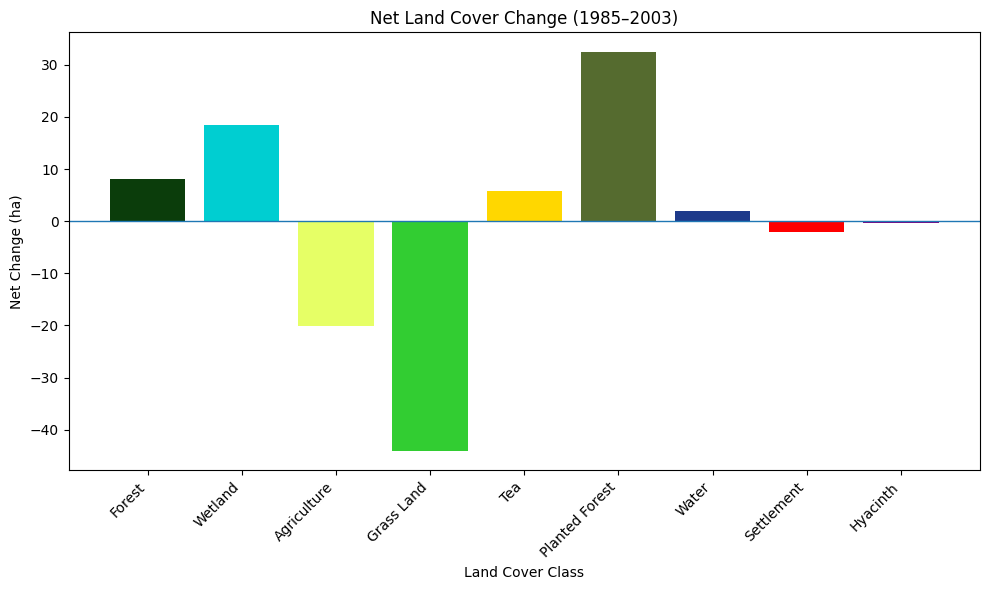

In [ ]:
import matplotlib.pyplot as plt
colors = [
    '#0B3D0B',  # Forest
    '#00CED1',  # Wetland
    '#E6FF66',  # Agriculture
    '#32CD32',  # Grass Land
    '#FFD700',  # Tea
    '#556B2F',  # Planted Forest
    '#1E3A8A',  # Water
    '#FF0000',  # Settlement
    '#800080'   # Hyacinth
]
plt.figure(figsize=(10,6))

plt.bar(
    df["Class"],
    df["Net_ha"],
    color=colors
)
plt.axhline(0, linewidth=1)
plt.xlabel("Land Cover Class")
plt.ylabel("Net Change (ha)")
plt.title("Net Land Cover Change (1985–2003)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()